In [2]:
using LinearAlgebra
using BoundaryValueDiffEq
using Plots
using DifferentialEquations
using BSplineKit
using DelimitedFiles

In [ ]:
##similar method##

In [ ]:
function sol_baseflowODE(tspan,Num)

    function oneDiskODE!(du, u , p, t)
        
        U = u[1]
        dU = u[2]
        V = u[3]
        dV = u[4]
        W = u[5]
        du[1] = dU
        ddU = U^2 + W*dU - (V+1.0e0)^2
        du[2] = ddU
        ddV = 2.0e0*U*(V + 1.0e0) + W*dV
        du[3] = dV
        du[4] = ddV                          
        du[5] = -2.0e0*U

    end
    function oneDiskbc!(residual, u , p, t)

        residual[1] = u[begin][1] 
        residual[2] = u[begin][3] 
        residual[3] = u[begin][5] 
        residual[4] = u[end][1] 

        residual[5] = u[end][3] + 1.0e0
    end
        prob = BVProblem(oneDiskODE!, oneDiskbc!, [0.0, 0.5103341351120374, 0.0, -0.6151547026271073, 0.0] ,tspan, dtmax=0.01)
        sol = solve(prob, Shooting(Vern7()), dt=0.001)
        t=range(0.0, 50, Num)
        u=sol(t)
    
    return u , t

end


In [ ]:
function velocity(u)

    U = u[1 , :]
    dU = u[2 , :]
    V = -1 * u[3 , :]
    dV = -1 * u[4 , :]
    W = u[5 , :]
    phi = 0.001 .* cumsum(U)
    N = itp = interpolate(t, U , BSplineOrder(4))
    N1 = itp = interpolate(t, dU , BSplineOrder(4))
    N2 = itp = interpolate(t, dV , BSplineOrder(4))
    N3 = itp = interpolate(t, phi , BSplineOrder(4))
    
    return N,N1,N2,N3,U,V,W,phi

end

In [ ]:
function sol_q(tspan,Num,initial_vec)
   
    function com_von_q(du,u,p,t)
        q = u[1]
        dq = u[2]
        du[1] = u[2]
        du[2] = -2 * sigma * N3(t) * u[2]
        
    end
    function bc1!(residual,u,p,t)
        residual[1] = u[begin][1] - 1
        residual[2] = u[end][1] 
        
    end
        prob = BVProblem(com_von_q, bc1!, initial_vec,tspan)
        sol = solve(prob, MIRK4(), dt=0.001)
        t = range(0.0, 20, Num)
        u = sol(t)
        q = u[1, :]
        dq = u[2,:]

    return q , dq

end

In [ ]:
function sol_f(tspan,Num,initial_vec)
    function com_von_f(du,u,p,t)
        f = u[1]
        df = u[2]
        du[1] = u[2]
        du[2] = -2 * sigma * N3(t) * u[2] + 2 * sigma * N(t) *u[1] + 2 * sigma * (N1(t)^2 + N2(t)^2) 
    end
    function bc2!(residual,u,p,t)
        residual[1] = u[begin][1] - 0
        residual[2] = u[end][1] - 0
    end
        prob = BVProblem(com_von_f, bc2!, initial_vec,tspan)
        sol = solve(prob, MIRK4(), dt=0.001)
        t = range(0.0, 20, Num)
        u = sol(t)
        f = u[1, :]
        df = u[2,:]

        return f , df
        
end

In [ ]:
function com_von_T(f ,q ,Mx ,gamma ,Tw)
    T = 1 .-(gamma-1)/2 * Mx^2 .* f .+ (Tw - 1) .*q
    return T
end
##
function com_von_W(phi,T)
    W = -2 * T .* phi
end

In [ ]:
function caculate_z(t :: StepRangeLen , gamma , Mx , Tw , f , q)
    start = t.ref.hi
    step = t.step.hi
    len = t.len
    z = zeros(len , 1)
    integ_f = 0
    integ_q = 0
    for i = 1 : len
        z[i,1] = t[i,1] - (gamma - 1) / 2 * Mx^2 * integ_f + (Tw - 1) * integ_q
        integ_f = f[i,1] * step + integ_f
        integ_q = q[i,1] * step + integ_q
    end
    return z
end

In [39]:
tspan = (0,20)
Num=20001
initial_vec = [0,0]
sigma = 0.7
Mx = 8
gamma = 1.4
u,t = sol_baseflowODE(tspan,Num)
N,N1,N2,N3,U,V,W,phi = velocity(u)
q , dq = sol_q(tspan,Num,initial_vec)
f , df = sol_f(tspan,Num,initial_vec)
data = t
for Tw = 0 : 0.4 : 2
    T = com_von_T(f ,q ,Mx ,gamma ,Tw)
    z = caculate_z(t , gamma , Mx , Tw , f , q)
    data = [data z T]
end

In [ ]:
##CFD method##


In [ ]:
function Cheb(u,v,w,N)

    θ = range(0,length=N+1,stop=pi)
    x = reshape(-cos.(θ), N+1, 1)
    c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
    X = repeat(x, 1, N+1);
    dX = X - X';
    D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
    D = D - diagm(vec(sum(D, dims=2))); 
    for i=1:N+1
        D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
    end
    for i=1:N+1
        x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
        if x[i]>50
            x[i]=50
        end
    end
    itpw=itp = interpolate(t, w , BSplineOrder(4))
    itpu=itp = interpolate(t, u , BSplineOrder(4))
    itpv=itp = interpolate(t, v , BSplineOrder(4))
    itpdu=itp = interpolate(t, du , BSplineOrder(4))
    itpdv=itp = interpolate(t, dv , BSplineOrder(4))
    U=zeros(N+1,1)
    V=zeros(N+1,1)
    W=zeros(N+1,1)
    p=zeros(N+1,1)
    for i=1:N+1
        U[i,1]=itpu(x[i])
        V[i,1]=itpv(x[i])
        W[i,1]=itpw(x[i])
    end
    return D,x,U,V,W
    
end 

In [187]:
N=99
xmax = 10
xspan = (0,xmax)
Nx = 1000
dx = xmax / Nx
u1,t = sol_baseflowODE((0,50),20000)
u = u1[1 , :]
du = u1[2 , :]
v = u1[3 , :]
dv = u1[4 , :]
w = u1[5 , :]
D,y,U,V,W = Cheb(u,v,w,N)


([-1485.0757575755622 1805.6950152868812 … -0.45465990554170715 0.22727272727272727; -451.2131111950007 225.54974962835007 … 0.22728110404086682 -0.11361193821676785; … ; 2.2184173201016728e-8 -4.437952081884951e-8 … -4.404145189086558e-5 8.810508795493978e-5; -0.0 0.0 … -0.0 0.0], [0.0; 0.001107865293640436; … ; 50.0; 50.0;;], [-1.809053133576053e-27; 0.000564655605677068; … ; 2.434807354664103e-16; 2.434807354664103e-16;;], [0.0; -0.0006823583950431847; … ; -0.9999999999999983; -0.9999999999999983;;], [0.0; -6.257914536627208e-7; … ; -0.884474110209612; -0.884474110209612;;])

In [188]:
d2U = D^2 * U
dU = D * U
d2V = D^2 * V
dV = D * V

100×1 Matrix{Float64}:
 -0.6159220196824772
 -0.6159213892328725
 -0.6159120227766893
 -0.6158716018956681
 -0.6157634155877204
 -0.615537104703838
 -0.6151296747733128
 -0.6144668151587973
 -0.6134644894045389
 -0.6120308044635304
  ⋮
 -6.00016291938359e-16
  3.4803470781851363e-16
 -1.8437716594601816e-16
  8.996335112693258e-17
 -3.747282175582471e-17
  1.1275702593849246e-17
 -2.358139725155972e-18
  1.4230153513872246e-19
  0.0

In [207]:
M = 82
U1 = U[2:M,1] .+ (1 ./ U[2:M,1]).* (d2U[2:M,1] .- W[2:M,1] .* (dU[2:M,1]) .- U[2:M,1].* U[2:M,1] .+ (V[2:M,1] .+ 1) .* (V[2:M,1] .+ 1))
V1 = V[2:M,1] .+ (1 ./ U[2:M,1]).* (d2V[2:M,1] .- W[2:M,1] .* (dV[2:M,1]) .- 2 * U[2:M,1] .* (V[2:M,1] .+ 1))
W1 = D[2:M,2:M] \ (U[2:M,1] - 3 * U1) 

81-element Vector{Float64}:
 -0.2248808140364749
 -1.6419949632194976e-5
 -0.22494202426442902
 -0.0001521824483091632
 -0.22529585602987243
 -0.0007703711937614143
 -0.22640598418751892
 -0.002434644329384252
 -0.2289322212249228
 -0.0058891737070704275
  ⋮
 -1.1406935257533783
 -0.8475625247425155
 -1.1514360146935465
 -0.8347724948203208
 -1.1687929421365795
 -0.8111034569140074
 -1.2039401990020913
 -0.7528630943727717
 -1.3259509453008564

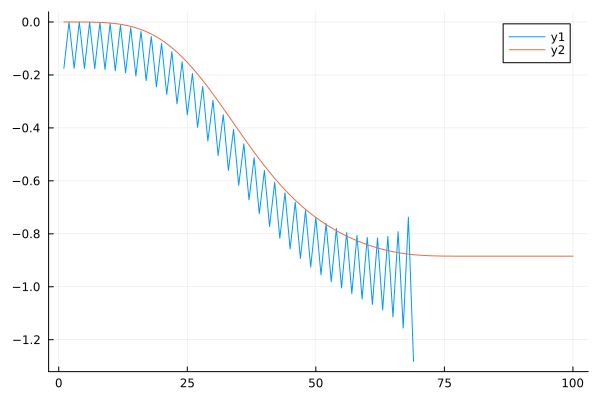

In [206]:
plot(W1)
plot!(W)